In [22]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

acceleration_data = pd.read_csv('Linear Acceleration.csv')
location_data = pd.read_csv('Location.csv')

In [32]:
#filter datas with high-pass filter
from scipy.signal import butter, filtfilt


def butter_lowpass_filter(data, cutoff, fs, nyq, order):
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def butter_highpass_filter(data, cutoff, fs, nyq, order):
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y



Time duration of the signal: 192.199407304 seconds


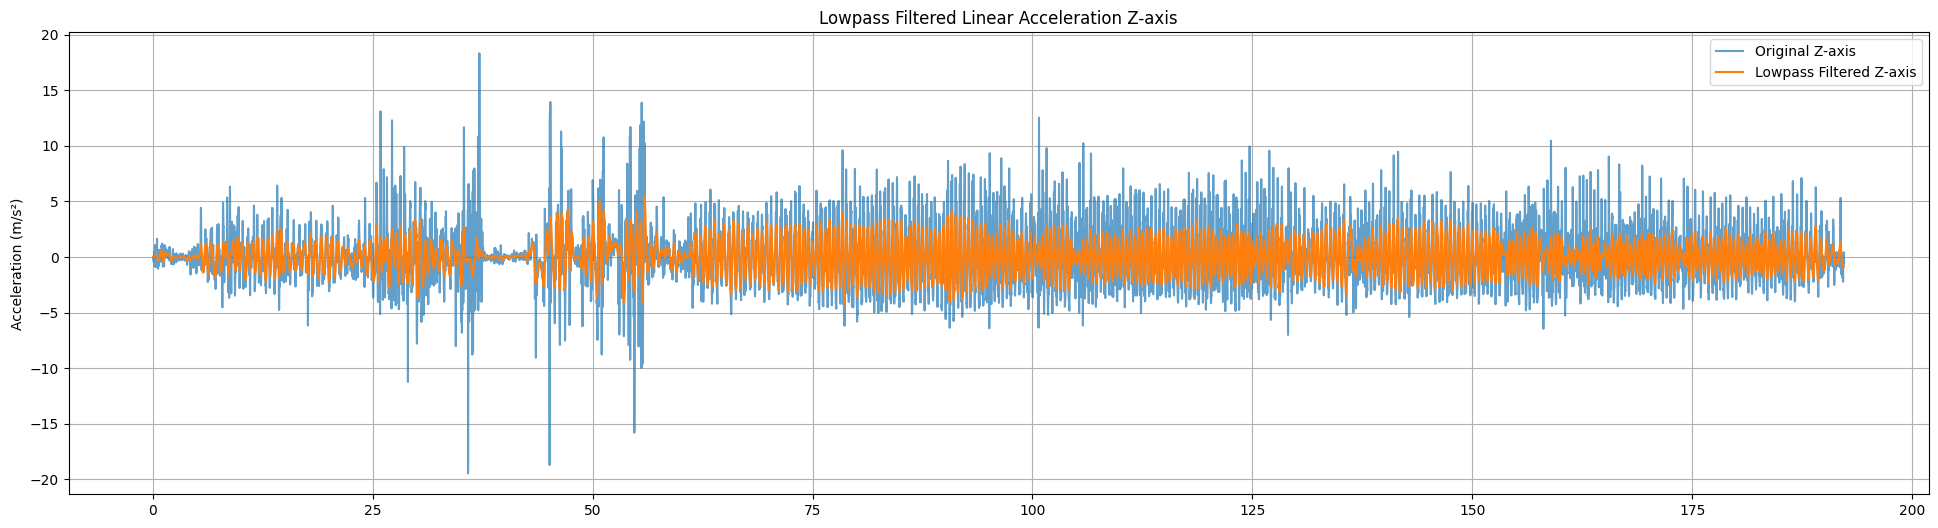

In [48]:

#T is the length of the signal
#last element minus first element means total time duration
t = acceleration_data['Time (s)'].iloc[-1] - acceleration_data['Time (s)'].iloc[0]
print(f'Time duration of the signal: {t} seconds')

fs = len(acceleration_data['Time (s)']) / t  # Sampling frequency
nyq = 0.5 * fs  # Nyquist Frequency
order = 3
cutoff_low = 2.5  # Desired cutoff frequency of the filter, Hz

filtered_z_low = butter_lowpass_filter(acceleration_data['Linear Acceleration z (m/s^2)'], cutoff_low, fs, nyq, order)


plt.figure(figsize=(24, 6))
plt.plot(acceleration_data['Time (s)'], acceleration_data['Linear Acceleration z (m/s^2)'], alpha=0.7)
plt.plot(acceleration_data['Time (s)'], filtered_z_low, label='Lowpass Filtered Z-axis')
plt.legend(('Original Z-axis','Lowpass Filtered Z-axis'))
plt.ylabel('Acceleration (m/s²)')
plt.title('Lowpass Filtered Linear Acceleration Z-axis')
plt.grid()
plt.show()


In [49]:
stepcount = 0

#calculate step count from filtered signal by finding local maxima
for i in range(1, len(filtered_z_low) - 1):
    if((filtered_z_low[i] > 0 and filtered_z_low[i] > filtered_z_low[i - 1] and filtered_z_low[i] > filtered_z_low[i + 1])):
        stepcount += 1

print(f"Total steps counted: {stepcount}.")

Total steps counted: 386.


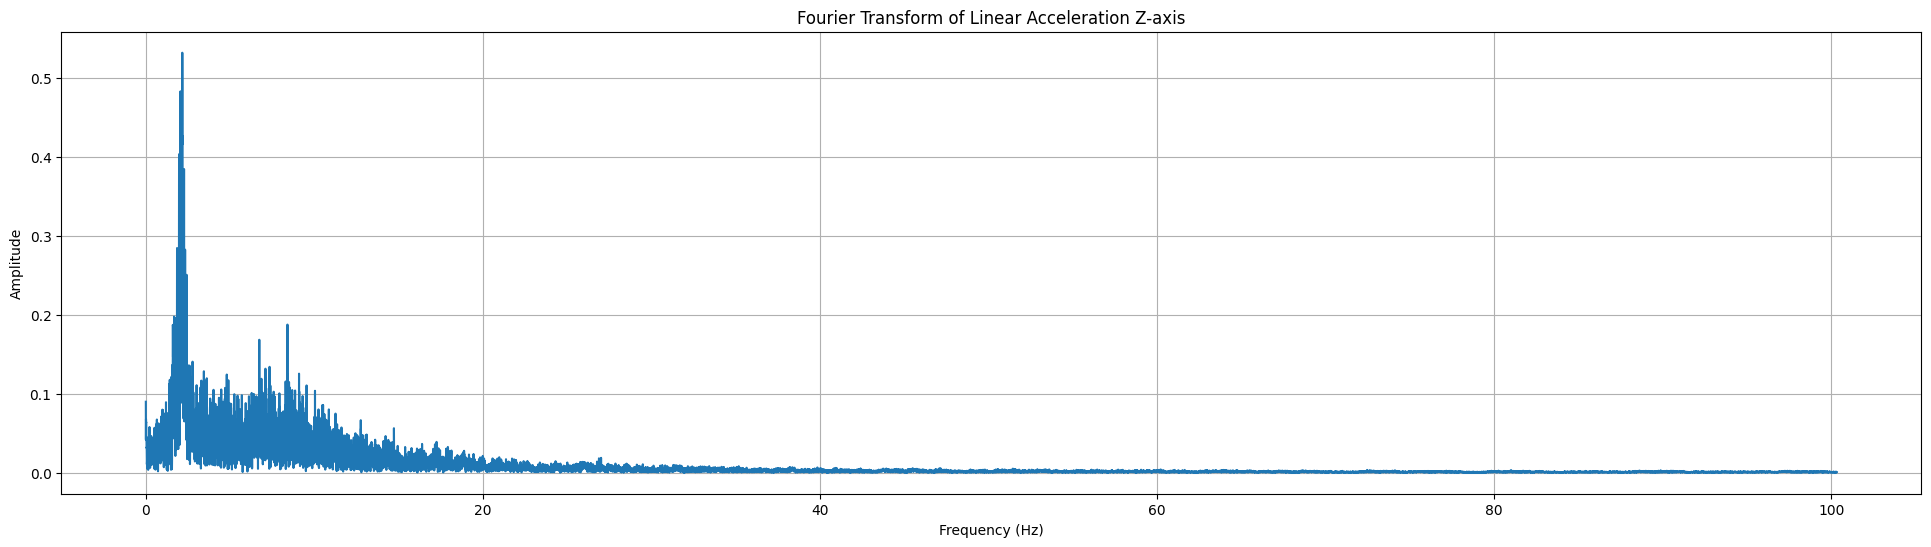

Peak frequency in the Fourier Transform: 2.1644187452774855 Hz
Calculated steps: 416.00000000000006.


In [53]:
#calculate step count from fourier transformed signal
from scipy.fft import fft, fftfreq
N = len(acceleration_data['Linear Acceleration z (m/s^2)'])

yf = fft(acceleration_data['Linear Acceleration z (m/s^2)'])
xf = fftfreq(N, 1 / fs)
plt.figure(figsize=(24, 6))
plt.plot(xf[:N // 2], 2.0 / N * np.abs(yf[:N // 2]))
plt.grid()
plt.title('Fourier Transform of Linear Acceleration Z-axis')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')

plt.show()


#find the peak frequency in the fourier transformed signal
amplitudes = 2.0 / N * np.abs(yf[:N // 2])
peak_freq_index = np.argmax(amplitudes)
peak_frequency = xf[peak_freq_index]
print(f"Peak frequency in the Fourier Transform: {peak_frequency} Hz")

#calculate step count from peak frequency
calculated_steps_fourier = peak_frequency * t
print(f"Calculated steps: {calculated_steps_fourier}.")


In [54]:

#use haversine formula for the distance calculation between two gps coordinates
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat / 2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


distance = 0.0

for i in range(1, len(location_data['Latitude (°)'])):
    lat1 = location_data['Latitude (°)'][i - 1]
    lon1 = location_data['Longitude (°)'][i - 1]
    lat2 = location_data['Latitude (°)'][i]
    lon2 = location_data['Longitude (°)'][i]
    distance += haversine(lat1, lon1, lat2, lon2)

print(f'Total distance traveled (in meters): {distance * 1000} meters')

location_data.head()



Total distance traveled (in meters): 302.2023228781179 meters


,Time (s),Latitude (°),Longitude (°),Height (m),Velocity (m/s),Direction (°),Horizontal Accuracy (m),Vertical Accuracy (m)
0,0.000000,65.016645,25.513220,19.732617,NaN,NaN,52.400002,7.641275
1,8.419551,65.016659,25.513184,-22.520607,0.96,99.099998,22.646555,67.270660
2,8.588364,65.016721,25.513245,11.167780,0.38,166.600006,5.547373,8.958246
3,9.587714,65.016750,25.513200,20.846120,0.00,NaN,5.151887,7.800425
4,10.587744,65.016775,25.513213,26.016459,0.00,NaN,4.340676,6.047642


In [37]:
#let's calculate average speed
average_speed = (distance * 1000) / t  # in meters per second
print(f'Average speed: {average_speed} m/s')

Average speed: 1.5723374339033591 m/s


In [38]:
import folium

map = folium.Map(location=[location_data['Latitude (°)'].mean(), location_data['Longitude (°)'].mean()], zoom_start=14)

for i in range(len(location_data['Latitude (°)'])):
    folium.CircleMarker(
        location=[location_data['Latitude (°)'][i], location_data['Longitude (°)'][i]],
        radius=2,
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(map)

folium.PolyLine(location_data[['Latitude (°)', 'Longitude (°)']], color='red').add_to(map)
map.save('location_map.html')
map
